Лабораторная работа 2

Базовый конвейер анализа данных в Pandas

Тупикин Михаил, ЕТ-212

# 3. Формирование и сохранение исходных данных

In [1]:
import numpy as np
import pandas as pd

raw_data = {
    "order_id": [
        1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010,
        1011, 1012, 1013, 1014, 1015
    ],

    "channel": [
        "site", "app", "app", "marketplace", "site",
        "app", "site", "marketplace", "app", "site",
        "marketplace", "app", "site", "site", "marketplace"
    ],

    "order_sum": [
        1200, 2500, 1800, 3200, 900,
        1500, 2800, 45000, 2100, 1700,
        3600, 1100, 2400, 1900, 3300
    ],

    "delivery_time": [
        25, np.nan, 40, 55, 20,
        30, np.nan, 70, 35, 45,
        50, 18, 27, np.nan, 60
    ],

    "rating": [
        5, 4, 5, 3, 5,
        4, 2, 1, 5, 4,
        3, 5, 4, 5, 2
    ]
}

df = pd.DataFrame(raw_data)

print(df)

df.to_csv("online_store_orders.csv", index=False)

    order_id      channel  order_sum  delivery_time  rating
0       1001         site       1200           25.0       5
1       1002          app       2500            NaN       4
2       1003          app       1800           40.0       5
3       1004  marketplace       3200           55.0       3
4       1005         site        900           20.0       5
5       1006          app       1500           30.0       4
6       1007         site       2800            NaN       2
7       1008  marketplace      45000           70.0       1
8       1009          app       2100           35.0       5
9       1010         site       1700           45.0       4
10      1011  marketplace       3600           50.0       3
11      1012          app       1100           18.0       5
12      1013         site       2400           27.0       4
13      1014         site       1900            NaN       5
14      1015  marketplace       3300           60.0       2


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


По умолчанию pandas пишет в CSV ещё и индекс строк отдельным безымянным столбцом. Параметр index=False это отключает — в файл идут только настоящие колонки. Иначе при чтении через pd.read_csv() появится мусорный столбец вроде Unnamed: 0, что ломает структуру данных и мешает анализу

# 4. Загрузка и первичный анализ данных

In [3]:
store_df = pd.read_csv("online_store_orders.csv")

print("Первые 5 строк")
print(store_df.head())

print("\nПоследние 5 строк:")
print(store_df.tail())

print("\nРазмер таблицы:")
print(store_df.shape)

print("\nНазвания столбцов:")
print(store_df.columns)

print("\nИнформация о таблице:")
print(store_df.info())

Первые 5 строк
   order_id      channel  order_sum  delivery_time  rating
0      1001         site       1200           25.0       5
1      1002          app       2500            NaN       4
2      1003          app       1800           40.0       5
3      1004  marketplace       3200           55.0       3
4      1005         site        900           20.0       5

Последние 5 строк:
    order_id      channel  order_sum  delivery_time  rating
10      1011  marketplace       3600           50.0       3
11      1012          app       1100           18.0       5
12      1013         site       2400           27.0       4
13      1014         site       1900            NaN       5
14      1015  marketplace       3300           60.0       2

Размер таблицы:
(15, 5)

Названия столбцов:
Index(['order_id', 'channel', 'order_sum', 'delivery_time', 'rating'], dtype='object')

Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 colu

15 строк

5 столбцов

4 числовых столбца

delivery_time - столбец с пропущенными значениями

3 пропущенных занчения

# 5. Выборка и фильтрация данных

In [ ]:
print(store_df[["order_sum", "delivery_time"]])

    order_sum  delivery_time
0        1200           25.0
1        2500            NaN
2        1800           40.0
3        3200           55.0
4         900           20.0
5        1500           30.0
6        2800            NaN
7       45000           70.0
8        2100           35.0
9        1700           45.0
10       3600           50.0
11       1100           18.0
12       2400           27.0
13       1900            NaN
14       3300           60.0


In [ ]:
slice_df = store_df[["order_sum", "delivery_time"]].iloc[3:8]
print(slice_df)

   order_sum  delivery_time
3       3200           55.0
4        900           20.0
5       1500           30.0
6       2800            NaN
7      45000           70.0


In [ ]:
premium_orders = store_df[(store_df["order_sum"] > 2000) & (store_df["rating"] == 5)]
print(premium_orders)

   order_id channel  order_sum  delivery_time  rating
8      1009     app       2100           35.0       5


Почему для объединения условий используется & , а не and ?

такой синтаксис

# 6. Проверка качества данных и статистический анализ

In [ ]:
store_df.isna().sum()

,0
order_id,0
channel,0
order_sum,0
delivery_time,3
rating,0


Сколько заказов не имеют информации о времени доставки?

3

In [ ]:
store_df.describe()

,order_id,order_sum,delivery_time,rating
count,15.000000,15.00000,12.000000,15.000000
mean,1008.000000,5000.00000,39.583333,3.800000
std,4.472136,11096.33144,16.654010,1.320173
min,1001.000000,900.00000,18.000000,1.000000
25%,1004.500000,1600.00000,26.500000,3.000000
50%,1008.000000,2100.00000,37.500000,4.000000
75%,1011.500000,3000.00000,51.250000,5.000000
max,1015.000000,45000.00000,70.000000,5.000000


Какой показатель имеет значение max , существенно отличающееся от остальных наблюдений?

order_sum. максимальное значение 45000, медиана 2100

In [ ]:
mean_delivery = store_df["delivery_time"].mean()
median_delivery = store_df["delivery_time"].median()

print("Среднее:", mean_delivery)
print("Медиана:", median_delivery)

Среднее: 39.583333333333336
Медиана: 37.5


Почему среднее значение может отличаться от медианы? Объясните ответ с учётом влияния выбросов

Среднее значение рассчитывается с учётом каждого элемента выборки, поэтому даже единичные экстремальные значения сильно сдвигают его. Медиана же устойчива к таким отклонениям: она делит данные пополам и не зависит от того, насколько велик выброс.

In [ ]:
store_df["rating"].value_counts()

,count
rating,
5,6
4,4
3,2
2,2
1,1


Какая оценка встречается наиболее часто?

5

# 7. Группировка и получение аналитического результата

In [ ]:
store_df["is_high_value"] = store_df["order_sum"] > 3000
print(store_df[["order_id", "order_sum", "is_high_value"]])

    order_id  order_sum  is_high_value
0       1001       1200          False
1       1002       2500          False
2       1003       1800          False
3       1004       3200           True
4       1005        900          False
5       1006       1500          False
6       1007       2800          False
7       1008      45000           True
8       1009       2100          False
9       1010       1700          False
10      1011       3600           True
11      1012       1100          False
12      1013       2400          False
13      1014       1900          False
14      1015       3300           True


In [ ]:
channel_stats = store_df.groupby("channel")["order_sum"].mean()
print(channel_stats)
print(store_df[store_df["order_sum"] < 45000].groupby("channel")["order_sum"].mean())

channel
app             1800.000000
marketplace    13775.000000
site            1816.666667
Name: order_sum, dtype: float64
channel
app            1800.000000
marketplace    3366.666667
site           1816.666667
Name: order_sum, dtype: float64


1.

app             1800.000000

marketplace    13775.000000

site            1816.666667

2. 4

3. 3 в delivery_time

4. сильно меняет среднее в сторону выброса

5. разница небольшая, так как отсутсвуют выбросы



# 8. Итоговый аналитический вывод

В наборе данных 15 заказов, при этом у 3 из них отсутствует информация о времени доставки. Средняя сумма заказа в каналах app (1800) и site (1816,67) практически совпадает, а в marketplace достигает 13 775. Такой разрыв объясняется заказом 1008 на сумму 45 000: без него средняя по marketplace снизилась бы до 3366,67 и стала бы сопоставимой с остальными каналами. Заказов дороже 3000 ₽ — 4. Среднее (39,58) и медианное (37,5) время доставки близки, поскольку выбросы отсутствуют. Таким образом, при интерпретации средней суммы заказа важно учитывать наличие выброса.

# 11. Дополнительное задание

<Axes: ylabel='Frequency'>

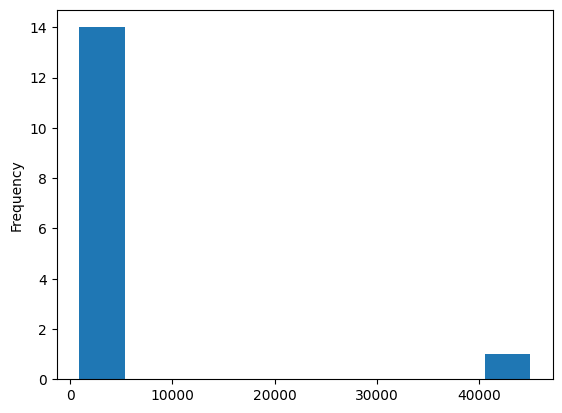

In [ ]:
store_df["order_sum"].plot(kind="hist")

Из-за единственного выброса ось X растянулась до 45 000, поэтому основная масса заказов отображается одним столбиком, и гистограмма не передаёт реальную картину распределения.